In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pickle
import importlib
import seaborn as sns
import torch

import config

from models import SingleTransformer
from train import train_mlm, train_cls
from evaluate import evaluate_mlm, evaluate_cls_cv
from data import load_data, create_dataset
from interpretation.metrics import compute_metrics_from_confusion_matrix
from interpretation.visualization import *

sns.set_style("whitegrid")
sns.set_palette("colorblind")
sns.set_context("paper", font_scale=1.5)

In [2]:
adata_ATAC_labelled, adata_ATAC_unlabelled = load_data.load_atac(data_path="data/datasets/atac/all_atac_d3_motif.h5ad",
                                                                 clone_info=True, clone_path="data/datasets/clone/clones.csv")
# with open('objects/atac_labelled.pkl', 'wb') as f:
#     pickle.dump(adata_ATAC_labelled, f)
# with open('objects/atac_unlabelled.pkl', 'wb') as f:
#     pickle.dump(adata_ATAC_unlabelled, f)


print("ATAC data loaded.",
        "\nATAC D3 Labelled:", adata_ATAC_labelled.shape, adata_ATAC_labelled.obs.shape,  list(adata_ATAC_labelled.var_names)[:5],"...",
        "\nATAC D3 Un-Labelled:", adata_ATAC_unlabelled.shape, adata_ATAC_unlabelled.obs.shape, list(adata_ATAC_unlabelled.var_names)[:5],"...")

ATAC data loaded. 
ATAC D3 Labelled: (265, 883) (265, 12) ['Tcfap2a_1', 'Tcfap2b_2', 'Tcfap2c_3', 'Tcfap2e_4', 'Tcfap2d_5'] ... 
ATAC D3 Un-Labelled: (54824, 883) (54824, 1) ['Tcfap2a_1', 'Tcfap2b_2', 'Tcfap2c_3', 'Tcfap2e_4', 'Tcfap2d_5'] ...


In [3]:
mlm_train_loader, mlm_val_loader = create_dataset.get_mlm_loaders(train_data=adata_ATAC_unlabelled, 
                                                                  val_data=adata_ATAC_labelled, 
                                                                  batch_size=32, 
                                                                  batch_key="batch_no", 
                                                                  data_dtype=torch.float32)

labelled_dataset, pcts, atac_names = create_dataset.get_cls_dataset(data=adata_ATAC_labelled,
                                                    batch_key="batch_no",
                                                    label_key="label",
                                                    pct_key="pct",
                                                    filter_pcts=10.0,
                                                    data_dtype=torch.float32)
print(len(labelled_dataset))

265


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_config = {
    "vocab_size": 1,
    "seq_len": next(iter(mlm_train_loader))[0].shape[-1],
    "d_model": 128,
    # "d_batch": 4,
    "d_ff": 16,
    "n_heads": 8,
    "n_encoder_layers": 2,
    "n_batches": 3,
    "dropout_rate": 0.2
}
model = SingleTransformer(id="ATAC", **model_config).to(device)

In [ ]:
mlm_train_loss, mlm_val_loss = train_mlm(model, mlm_train_loader, mlm_val_loader, device,
                                            mse_based=True, epochs=10, lr=1e-3, weight_decay=0, tune_lr=True, 
                                            save_folder="ckp/MLM/", id="ATAC", use_multiple_gpu=False)
plot_training_vs_validation_losses(mlm_train_loss, mlm_val_loss, "MLM")

In [6]:
importlib.reload(config)
model.load_state_dict(torch.load(config.MLM_ATAC_CKP))
print(f"Model loaded from checkpoint: {config.MLM_ATAC_CKP}")
val_loss = evaluate_mlm(model, mlm_val_loader, mask_token=-1, mse_based=True, device=device)
print(f"Validation Loss: {val_loss:.4f}")

Model loaded from checkpoint: ckp/MLM/MLM_ATAC_ValLoss0.0019.pth


Evaluating MLM:   0%|          | 0/9 [00:00<?, ?it/s]

Validation Loss: 0.0020


In [ ]:
importlib.reload(config)
fold_results = train_cls("ATAC", model_config, 
                        labelled_dataset, k_folds=5, batch_size=32, 
                        epochs=15, lr=1e-3, weight_decay=1e-4,
                        use_mlm=True, mlm_path="ckp/MLM/MLM_ATAC_ValLoss0.0019.pth", save_path="ckp/CLS", 
                        device=device, loss_fn="w_bce", seed=0)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}, "
    f"Precision: {np.mean([fr['best_precision'] for fr in fold_results]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results]):.4f}, "
    f"Recall: {np.mean([fr['best_recall'] for fr in fold_results]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results]):.4f}, "
    f"F1: {np.mean([fr['best_f1'] for fr in fold_results]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results]):.4f}, "
    f"Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results]):.4f}")

In [ ]:
fold_results_nomlm = train_cls("ATAC", model_config, 
                            labelled_dataset, k_folds=5, batch_size=32, 
                            epochs=15, lr=1e-3, weight_decay=1e-4,
                            use_mlm=False, mlm_path=None, save_path="ckp/CLS", 
                            device=device, loss_fn="w_bce", seed=0)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Precision: {np.mean([fr['best_precision'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results_nomlm]):.4f}, "
    f"Recall: {np.mean([fr['best_recall'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results_nomlm]):.4f}, "
    f"F1: {np.mean([fr['best_f1'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results_nomlm]):.4f}, "
    f"Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f}")

In [5]:
# with open('objects/atac_fold_results_mlm_last_l_conc1.pkl', 'wb') as f:
#     pickle.dump(fold_results, f)
# with open('objects/atac_fold_results_nomlm_last_l_conc.pkl', 'wb') as f:
#     pickle.dump(fold_results_nomlm, f)

with open('objects/atac_fold_results_mlm_last_l_conc1.pkl', 'rb') as f:
    fold_results = pickle.load(f)
with open('objects/atac_fold_results_nomlm_last_l_conc.pkl', 'rb') as f:
        fold_results_nomlm = pickle.load(f)

In [7]:
# compute mean and std of train_auc and best_val_auc keys in fold_results and fold_results_nomlm
train_auc_mlm = np.mean([fr['train_auc'] for fr in fold_results])
train_auc_nomlm = np.mean([fr['train_auc'] for fr in fold_results_nomlm])
train_auc_mlm_std = np.std([fr['train_auc'] for fr in fold_results])
train_auc_nomlm_std = np.std([fr['train_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm = np.mean([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm = np.mean([fr['best_val_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm_std = np.std([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm_std = np.std([fr['best_val_auc'] for fr in fold_results_nomlm])

print(f"Train AUC: MLM: {train_auc_mlm:.4f} ± {train_auc_mlm_std:.4f}, No-MLM: {train_auc_nomlm:.4f} ± {train_auc_nomlm_std:.4f}")
print(f"Best Val AUC: MLM: {best_val_auc_mlm:.4f} ± {best_val_auc_mlm_std:.4f}, No-MLM: {best_val_auc_nomlm:.4f} ± {best_val_auc_nomlm_std:.4f}")

Train AUC: MLM: 0.8931 ± 0.0403, No-MLM: 0.6283 ± 0.0157
Best Val AUC: MLM: 0.8852 ± 0.0540, No-MLM: 0.6393 ± 0.0753


In [10]:
# print each fold best val auc separate based on mlm and no mlm 5 folds for each)
for i in range(5):
    print(f"Fold {i+1}: MLM: {fold_results[i]['best_val_auc']:.4f}, No-MLM: {fold_results_nomlm[i]['best_val_auc']:.4f}")
print(f"val auc mlm: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}")
print(f"val auc no mlm: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}")
# compute p-value for mlm and no-mlm values for val auc
from scipy.stats import ttest_rel
print("p-value for val auc: ", ttest_rel([fr['best_val_auc'] for fr in fold_results], [fr['best_val_auc'] for fr in fold_results_nomlm]))

Fold 1: MLM: 0.8834, No-MLM: 0.6605
Fold 2: MLM: 0.8970, No-MLM: 0.6081
Fold 3: MLM: 0.9368, No-MLM: 0.6509
Fold 4: MLM: 0.9246, No-MLM: 0.7544
Fold 5: MLM: 0.7842, No-MLM: 0.5228
val auc mlm: 0.8852 ± 0.0540
val auc no mlm: 0.6393 ± 0.0753
p-value for val auc:  TtestResult(statistic=11.023269570027491, pvalue=0.000384990770818786, df=4)


Evaluating Classifier: 0it [00:00, ?it/s]

['(0.8834 | 0.8834)', '(0.8970 | 0.8970)', '(0.9368 | 0.9368)', '(0.9246 | 0.9246)', '(0.7842 | 0.7842)']


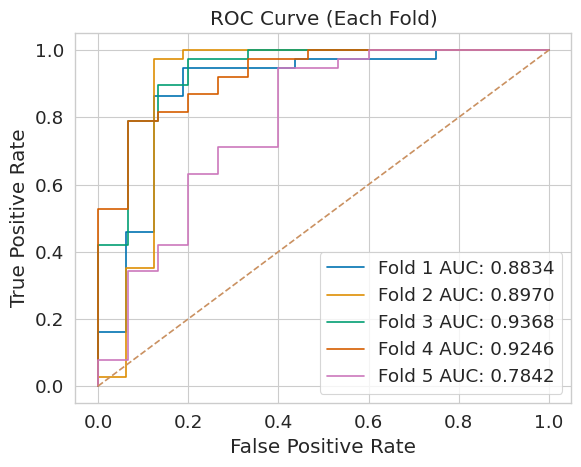

In [11]:
aucs_stored, aucs, val_preds, val_labels = evaluate_cls_cv("ATAC", fold_results, model_config, labelled_dataset, device)
print([f"({a:.4f} | {b:.4f})" for a,b in zip(aucs_stored, aucs)])
plot_roc_auc_curve(val_preds, val_labels, m_type="ATAC", aggregate=False)